## Landscape Hacking 8b


In [2]:
import json, math, zlib
from pathlib import Path
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.models.resnet import ResNet, BasicBlock
import torchvision.datasets as dsets
import torchvision.transforms as T
from tqdm.auto import tqdm
import glob
import matplotlib.pyplot as plt

device = (
    "cuda" if torch.cuda.is_available()
    # else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
# RUNS = Path("overnight_runs")                               # <-- edit if needed
RUNS = Path("curated_checkpoints")
DATA = Path("/home/stephen/imagenet")   #Linux
# DATA = Path("/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/resnet/hackin/imagenet") #Mac
crit = nn.CrossEntropyLoss()
print(torch.__version__, device)

2.12.1+cu130 cuda


In [2]:
STAGE_CONFIGS = {14: [2,1,1,2], 20: [2,2,3,2], 26: [3,3,3,3],
                 30: [3,4,4,3], 34: [3,4,6,3], 50: [3,6,9,6],
                 56: [3, 4, 17, 3], 74: [3, 4, 26, 3], 110: [3, 4, 44, 3]}

class PlainBasicBlock(BasicBlock):
    """torchvision BasicBlock with the skip connection removed."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.downsample = None
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        return self.relu(self.bn2(self.conv2(out)))

def make_net(depth, use_skip, num_classes=1000):
    return ResNet(BasicBlock if use_skip else PlainBasicBlock,
                  STAGE_CONFIGS[depth], num_classes=num_classes)

def weighted_layers(model):
    """(name, module) for convs + fc in forward order, excluding 1x1 shortcuts."""
    return [(n, m) for n, m in model.named_modules()
            if isinstance(m, (nn.Conv2d, nn.Linear)) and "downsample" not in n]

def list_layers(model):
    for i, (n, m) in enumerate(weighted_layers(model)):
        print(f"{i:3d}  {n:<22} {tuple(m.weight.shape)}")

In [3]:
def parse_tag(tag):
    d, s = tag.split("_")
    return int(d[1:]), s == "skip"

def load_model(tag, step="latest", runs=RUNS, init_seed=0):
    """step="latest" or int -> load checkpoint. step=None or "random" ->
    fresh Kaiming init (reproducible via init_seed)."""
    depth, use_skip = parse_tag(tag)
    m = make_net(depth, use_skip).to(device)
    if step is None or step == "random":
        torch.manual_seed(init_seed)   # note: after construction this only seeds nothing —
        # for a reproducible init, seed BEFORE make_net:
        torch.manual_seed(init_seed); m = make_net(depth, use_skip).to(device)
    else:
        pattern = f"{tag}*.pt" if step == "latest" else f"{tag}*step{step}*.pt"
        matches = sorted(glob.glob(str(runs / pattern)))
        assert matches, f"no checkpoint matching {pattern} in {runs}"
        ck = torch.load(matches[-1], map_location=device)
        if 'model' in ck:
             m.load_state_dict(ck["model"])
        else:
            m.load_state_dict(ck) #["model"])
        print(f"loaded {matches[-1]}")
    m.eval()
    return m

### Load up Models & dataset

In [4]:
model_skip=load_model('d14_skip', runs=RUNS)
model_noskip=load_model('d14_noskip', runs=RUNS)

# model_skip=load_model('d74_skip', runs=RUNS)
# model_noskip=load_model('d74_noskip', runs=RUNS)

loaded curated_checkpoints/d14_skip_30000.pt
loaded curated_checkpoints/d14_noskip_30000.pt


In [5]:
norm = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
train_ds = dsets.ImageFolder(DATA / "ILSVRC/Data/CLS-LOC/train",
    T.Compose([T.RandomResizedCrop(224), T.RandomHorizontalFlip(), T.ToTensor(), norm]))
val_ds = dsets.ImageFolder(DATA / "ILSVRC/Data/CLS-LOC/val",
    T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(), norm]))

BATCH = 256  # drop if you hit OOM
train_loader = torch.utils.data.DataLoader(train_ds, BATCH, shuffle=True,
    num_workers=8, pin_memory=True, drop_last=True, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(val_ds, BATCH, shuffle=False,
    num_workers=8, pin_memory=True)
print(len(train_ds), len(val_ds))

1281167 50000


### Check Model Accuracy on Validation Set

In [6]:
# @torch.no_grad()
# def validate(model, loader):
#     model.eval()
#     top1 = top5 = total = 0
#     for x, y in tqdm(loader, desc="val"):
#         x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
#         with torch.amp.autocast(device, enabled=(device == "cuda")):
#             logits = model(x)
#         _, pred5 = logits.topk(5, dim=1)
#         correct = pred5.eq(y.unsqueeze(1))
#         top1 += correct[:, 0].sum().item()
#         top5 += correct.any(dim=1).sum().item()
#         total += y.numel()
#     return top1 / total, top5 / total

# acc1, acc5 = validate(model, val_loader)
# print(f"top-1: {acc1:.4f}   top-5: {acc5:.4f}")

## Lots of Loss Landscape Renders

In [7]:
# ---- 2D landscape sweep: config + helpers ----
SWEEP_LAYER_IDXS = [-1, -2, -3, -4]   # layers to perturb (indices into weighted_layers)
N_IMAGES     = 32                  # random val images to step through
N_DIRECTIONS = 3                  # random direction pairs to try per image
GRID_N       = 74                 # GRID_N x GRID_N loss evals per model per surface
EXTENT       = 2.5                # alpha, beta range: [-EXTENT, EXTENT]
IMG_SEED     = 25                  # seed for choosing which val images
DIR_SEED_START = 25                # direction seeds used: DIR_SEED_START ... +N_DIRECTIONS-1
LOSS_CAP     = 25.0               # clip for plotting only

alphas = np.linspace(-EXTENT, EXTENT, GRID_N)
betas  = np.linspace(-EXTENT, EXTENT, GRID_N)

def filter_normalize_(d, w):
    """In-place: rescale each filter of d (row for Linear) to match w's filter norm."""
    d2, w2 = d.flatten(1), w.flatten(1)
    d2.mul_(w2.norm(dim=1, keepdim=True) / (d2.norm(dim=1, keepdim=True) + 1e-10))
    return d

def make_directions(model, layer_idxs, seed):
    """Two filter-normalized random directions over ONLY the selected layers.
    Same seed -> same Gaussian draw for both models; normalization adapts to
    each model's own filter norms (Li et al. 2018)."""
    g = torch.Generator().manual_seed(seed)
    layers = weighted_layers(model)
    dirs = []
    for _ in range(2):
        d = {}
        for i in layer_idxs:
            name, m = layers[i]
            r = torch.randn(m.weight.shape, generator=g).to(device)
            d[name] = filter_normalize_(r, m.weight.data)
        dirs.append(d)
    return dirs  # [delta, eta]

@torch.no_grad()
def loss_surface(model, delta, eta, x, y):
    layers = dict(weighted_layers(model))
    orig = {n: layers[n].weight.data.clone() for n in delta}
    Z = np.empty((GRID_N, GRID_N))
    for i, b in enumerate(betas):
        for j, a in enumerate(alphas):
            for n in delta:
                layers[n].weight.data.copy_(orig[n] + a * delta[n] + b * eta[n])
            with torch.amp.autocast(device_type=device, enabled=(device == "cuda")):
                Z[i, j] = crit(model(x), y).item()
    for n in delta:                      # restore!
        layers[n].weight.data.copy_(orig[n])
    return Z

In [8]:
# ---- run: images x direction seeds, one 2-panel figure each ----
rng = np.random.default_rng(IMG_SEED)
img_idxs = rng.choice(len(val_ds), size=N_IMAGES, replace=False)
dir_seeds = range(DIR_SEED_START, DIR_SEED_START + N_DIRECTIONS)

layer_str = "-".join(map(str, SWEEP_LAYER_IDXS))
out_dir = Path(f"landscapes_2d/d14_layers{layer_str}_ext{EXTENT}_grid{GRID_N}")
out_dir.mkdir(parents=True, exist_ok=True)

A, B = np.meshgrid(alphas, betas)
total = N_IMAGES * N_DIRECTIONS
pbar = tqdm(total=total, desc="surfaces")

for img_idx in img_idxs:
    x, y = val_ds[img_idx]
    x = x.unsqueeze(0).to(device)
    y = torch.tensor([y], device=device)
    cls = val_ds.classes[y.item()]

    for ds_ in dir_seeds:
        ds_=ds_+img_idx.item() #I want to increment through these
        delta_p, eta_p = make_directions(model_noskip, SWEEP_LAYER_IDXS, seed=ds_)
        delta_r, eta_r = make_directions(model_skip,   SWEEP_LAYER_IDXS, seed=ds_)

        Z_p = loss_surface(model_noskip, delta_p, eta_p, x, y)
        Z_r = loss_surface(model_skip,   delta_r, eta_r, x, y)

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        for ax, Z, title in [(axes[0], Z_p, "plainnet (no skip)"),
                             (axes[1], Z_r, "resnet (skip)")]:
            Zc = np.clip(Z, None, LOSS_CAP)
            cs = ax.contourf(A, B, Zc, levels=25, cmap="viridis")
            ax.contour(A, B, Zc, levels=25, colors="k", linewidths=0.3, alpha=0.4)
            ax.plot(0, 0, "r+", ms=10)
            ax.set_title(f"{title}   min {Z.min():.2f}  max {Z.max():.1f}")
            ax.set_xlabel(r"$\alpha$"); ax.set_ylabel(r"$\beta$")
            fig.colorbar(cs, ax=ax, shrink=0.9)
        fig.suptitle(f"d74  layers {SWEEP_LAYER_IDXS}  img {img_idx} ({cls})  dirseed {ds_}")
        fig.tight_layout()
        fig.savefig(out_dir / f"img{img_idx:06d}_dirseed{ds_:04d}.png", dpi=150)
        plt.close(fig)
        pbar.update(1)

pbar.close()
print(f"saved {total} figures -> {out_dir}/")

surfaces:   0%|          | 0/96 [00:00<?, ?it/s]

saved 96 figures -> landscapes_2d/d14_layers-1--2--3--4_ext2.5_grid74/


In [9]:
img_idx.item()

27273

## Gradient Fields

In [10]:
# ---- loss + in-plane gradient field over the 2D slice ----
QUIVER_STRIDE = 2     # plot every k-th arrow (bump to 2 if GRID_N is large)

def grad_surface(model, delta, eta, x, y):
    """Returns Z (loss), Ga (dL/dalpha = grad . delta), Gb (dL/dbeta = grad . eta)
    at each (alpha, beta) grid point. One forward+backward per point."""
    layers = dict(weighted_layers(model))
    orig = {n: layers[n].weight.data.clone() for n in delta}
    Z  = np.empty((GRID_N, GRID_N))
    Ga = np.empty((GRID_N, GRID_N))
    Gb = np.empty((GRID_N, GRID_N))
    for i, b in enumerate(betas):
        for j, a in enumerate(alphas):
            with torch.no_grad():
                for n in delta:
                    layers[n].weight.data.copy_(orig[n] + a * delta[n] + b * eta[n])
            model.zero_grad(set_to_none=True)
            with torch.enable_grad():
                with torch.amp.autocast(device_type=device, enabled=(device == "cuda")):
                    loss = crit(model(x), y)
                loss.backward()
            Z[i, j] = loss.item()
            ga = gb = 0.0
            with torch.no_grad():
                for n in delta:
                    g = layers[n].weight.grad
                    ga += (g * delta[n]).sum().item()
                    gb += (g * eta[n]).sum().item()
            Ga[i, j], Gb[i, j] = ga, gb
    with torch.no_grad():
        for n in delta:
            layers[n].weight.data.copy_(orig[n])
    model.zero_grad(set_to_none=True)
    return Z, Ga, Gb

In [11]:
# ---- run: gradient vector fields over images x direction seeds ----
rng = np.random.default_rng(IMG_SEED)
img_idxs = rng.choice(len(val_ds), size=N_IMAGES, replace=False)
dir_seeds = range(DIR_SEED_START, DIR_SEED_START + N_DIRECTIONS)

layer_str = "-".join(map(str, SWEEP_LAYER_IDXS))
out_dir = Path(f"gradfields_2d/d14_layers{layer_str}_ext{EXTENT}_grid{GRID_N}")
out_dir.mkdir(parents=True, exist_ok=True)

A, B = np.meshgrid(alphas, betas)
s = QUIVER_STRIDE
pbar = tqdm(total=N_IMAGES * N_DIRECTIONS, desc="grad fields")

for img_idx in img_idxs:
    x, y = val_ds[img_idx]
    x = x.unsqueeze(0).to(device)
    y = torch.tensor([y], device=device)
    cls = val_ds.classes[y.item()]

    for ds_ in dir_seeds:
        delta_p, eta_p = make_directions(model_noskip, SWEEP_LAYER_IDXS, seed=ds_)
        delta_r, eta_r = make_directions(model_skip,   SWEEP_LAYER_IDXS, seed=ds_)

        Z_p, Ga_p, Gb_p = grad_surface(model_noskip, delta_p, eta_p, x, y)
        Z_r, Ga_r, Gb_r = grad_surface(model_skip,   delta_r, eta_r, x, y)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, Z, Ga, Gb, title in [
            (axes[0], Z_p, Ga_p, Gb_p, "plainnet (no skip)"),
            (axes[1], Z_r, Ga_r, Gb_r, "resnet (skip)"),
        ]:
            Zc = np.clip(Z, None, LOSS_CAP)
            ax.contourf(A, B, Zc, levels=25, cmap="viridis", alpha=0.85)
            # descent direction: arrows unit-length, colored by log10 |grad|
            M = np.sqrt(Ga**2 + Gb**2)
            U, V = -Ga / (M + 1e-12), -Gb / (M + 1e-12)
            q = ax.quiver(A[::s, ::s], B[::s, ::s], U[::s, ::s], V[::s, ::s],
                          np.log10(M[::s, ::s] + 1e-12),
                          cmap="autumn", scale=30, width=0.004)
            fig.colorbar(q, ax=ax, shrink=0.85, label=r"$\log_{10}\,\|\nabla_{plane} L\|$")
            ax.plot(0, 0, "w+", ms=12, mew=2)
            ax.set_title(f"{title}   |g| med {np.median(M):.2f}")
            ax.set_xlabel(r"$\alpha$"); ax.set_ylabel(r"$\beta$")
        fig.suptitle(f"d74  layers {SWEEP_LAYER_IDXS}  img {img_idx} ({cls})  dirseed {ds_}")
        fig.tight_layout()
        fig.savefig(out_dir / f"img{img_idx:06d}_dirseed{ds_:04d}.png", dpi=150)
        plt.close(fig)
        pbar.update(1)

pbar.close()
print(f"done -> {out_dir}/")

grad fields:   0%|          | 0/96 [00:00<?, ?it/s]

done -> gradfields_2d/d14_layers-1--2--3--4_ext2.5_grid74/


NameError: name 'MODELS' is not defined

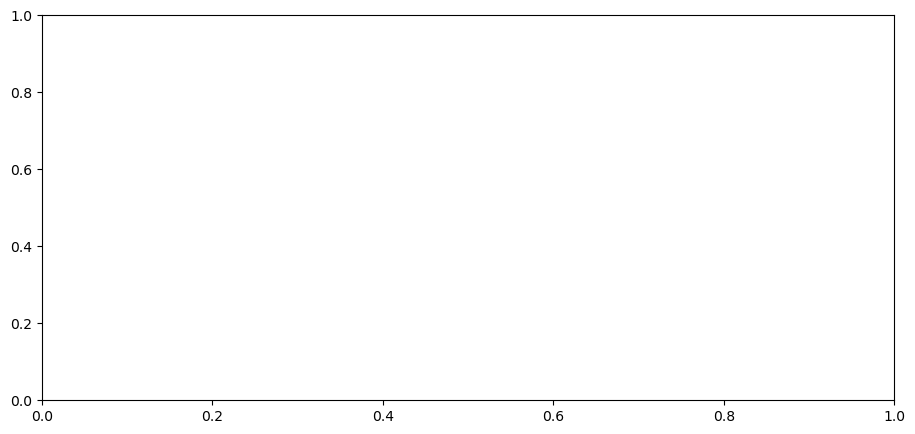

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for m in MODELS:
    ax.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m,
            lw=1.4, alpha=0.9)
ax.set(xlabel="step", ylabel="top-1 accuracy",
       title="quick val (5k subset), every 100 steps")
ax.legend(ncol=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()